# SHMS Reduced-Data MLP 校准验证（Notebook版）

本笔记本将 `train_reduced_mlp.py` 训练流程迁移到交互式 Notebook，并新增可视化：

- 全量训练（不做 training fraction 扫描）下的 RMSE/MAE
- 预测 vs 真值散点图（parity plot）
- 残差分布图
- 训练损失曲线

支持自动识别 ROOT 分支前缀 `ps*` 或 `hs*`。

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from datetime import datetime
from typing import Any
import math
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import uproot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [2]:
# ===== 配置区（按需修改） =====
ROOT_FILE = Path('C:\\Users\\Lanto\\Desktop\\AI_ML R-SIDIS\\mc-single-arm\\worksim\\shms_extended_nosieve.root')  # 若从 SHMS_Calibration_NN 目录启动
INP_FILE = Path('C:\\Users\\Lanto\\Desktop\\AI_ML R-SIDIS\\mc-single-arm\\infiles\\shms_extended_nosieve.inp')

TREE_NAME = 'h10'
TARGET_MODE = 'all'  # 'core3' | 'all' | 'delta-only'
FILTER_STOP_ID = True  # 仅保留 stop_id == 0 成功传输事件
MAX_EVENTS = 100_000
VAL_FRACTION = 0.20
EPOCHS = 60
BATCH_SIZE = 2048
LR = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 42

# 第一轮 all/ytar 优化：先减少多任务冲突，再看信息瓶颈
MODEL_HIDDEN = 192
MODEL_BLOCKS = 3
DROPOUT = 0.10
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 12
EARLY_STOPPING_MIN_DELTA = 1e-4
SCHEDULER_PATIENCE = 4
SCHEDULER_FACTOR = 0.5
MIN_LR = 1e-5

# 多任务 loss 权重：先降低 ytar 对共享 backbone 的拖拽
TARGET_LOSS_WEIGHTS = {
    'delta': 1.0,
    'xptar': 1.0,
    'yptar': 1.0,
    'ytar': 0.35,
}

# ytar 诊断开关
RUN_YTAR_FEATURE_DIAGNOSTICS = True
RUN_YTAR_ONLY_PROBE = False

# P0 默认从 .inp 自动解析；若想手动固定可改成具体数值（单位 GeV/c）
P0_OVERRIDE: float | None = None

# x_tar 使用确定性常数 0，避免注入随机噪声破坏监督映射
X_TAR_MODE = 'zero'  # 'zero' | 'random'
X_TAR_SIGMA = 0.1    # 仅在 X_TAR_MODE='random' 时生效

# 输出目录：兼容两种启动位置
OUTPUT_DIR = Path('outputs_notebook')
if Path.cwd().name != 'mlp_reduced_data_test':
    OUTPUT_DIR = Path('experiments/mlp_reduced_data_test/outputs_notebook')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT_FILE =', ROOT_FILE.resolve())
print('INP_FILE  =', INP_FILE.resolve() if INP_FILE.exists() else '(not found)')
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())
print('Model config =', {'hidden': MODEL_HIDDEN, 'blocks': MODEL_BLOCKS, 'dropout': DROPOUT})
print('Loss weights =', TARGET_LOSS_WEIGHTS)

ROOT_FILE = C:\Users\Lanto\Desktop\AI_ML R-SIDIS\mc-single-arm\worksim\shms_extended_nosieve.root
INP_FILE  = C:\Users\Lanto\Desktop\AI_ML R-SIDIS\mc-single-arm\infiles\shms_extended_nosieve.inp
OUTPUT_DIR = C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\mlp_reduced_data_test\outputs_notebook
Model config = {'hidden': 192, 'blocks': 3, 'dropout': 0.1}
Loss weights = {'delta': 1.0, 'xptar': 1.0, 'yptar': 1.0, 'ytar': 0.35}


In [3]:
def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)


def detect_prefix(branches: list[str]) -> str:
    for pref in ['ps', 'hs']:
        required = [f'{pref}xfp', f'{pref}yfp', f'{pref}xpfp', f'{pref}ypfp', f'{pref}deltai']
        if all(r in branches for r in required):
            return pref
    raise RuntimeError('Cannot detect branch prefix. Expected ps* or hs* branches.')


def infer_p0_from_inp(inp_file: Path) -> float | None:
    if not inp_file.exists():
        return None
    target_keywords = ('Spectrometer central momentum', 'Spectrometer momentum')
    for line in inp_file.read_text(encoding='utf-8', errors='ignore').splitlines():
        if any(k in line for k in target_keywords):
            # 从整行中提取第一个可解析浮点值（兼容是否有 '|' 注释分隔）
            for token in line.replace(',', ' ').split():
                try:
                    p0_mev = float(token)
                    return p0_mev / 1000.0
                except ValueError:
                    continue
    return None


def infer_reco_branch(pref: str, truth_branch: str, all_branches: list[str]) -> str | None:
    stripped = truth_branch[len(pref):] if truth_branch.startswith(pref) else truth_branch
    candidates: list[str] = []

    manual = {
        'deltai': [f'{pref}delta', f'{pref}deltar'],
        'xptari': [f'{pref}xptar'],
        'yptari': [f'{pref}yptar'],
        'ztari': [f'{pref}ztar', f'{pref}ytar'],
    }
    if stripped in manual:
        candidates.extend(manual[stripped])

    if stripped.endswith('i'):
        candidates.append(f'{pref}{stripped[:-1]}')

    for c in candidates:
        if c in all_branches:
            return c
    return None


def align_reco_to_truth(
    pref: str,
    truth_branch: str,
    reco_branch: str | None,
    reco_values: np.ndarray,
) -> tuple[np.ndarray, str | None]:
    if reco_branch is None:
        return reco_values, None

    if truth_branch == f'{pref}ztari' and reco_branch in {f'{pref}ztar', f'{pref}ytar'}:
        # Notebook 中的 ytar 目标实际采用 ztari 作为真值代理；
        # ROOT 的 ztar/ytar 与该代理约定相比需要翻转符号后再比较。
        return -reco_values, f'-{reco_branch}'

    return reco_values, reco_branch


@dataclass
class DataBundle:
    X: np.ndarray
    Y: np.ndarray
    Y_reco: np.ndarray
    feature_names: list[str]
    target_names: list[str]
    target_truth_branches: list[str]
    target_reco_branches: list[str | None]
    prefix: str
    n_all: int
    n_after_filter: int


def load_data(
    root_file: Path,
    tree_name: str,
    target_mode: str,
    p0: float,
    x_tar_mode: str,
    x_tar_sigma: float,
    max_events: int,
    seed: int,
    filter_stop_id: bool,
) -> DataBundle:
    rf: Any = uproot.open(root_file)
    tree = rf[tree_name]
    branches = list(tree.keys())

    pref = detect_prefix(branches)
    input_branches = [f'{pref}xfp', f'{pref}yfp', f'{pref}xpfp', f'{pref}ypfp']

    if target_mode == 'all':
        target_branches = [f'{pref}deltai', f'{pref}xptari', f'{pref}yptari', f'{pref}ztari']
        target_names = ['delta', 'xptar', 'yptar', 'ytar']
    elif target_mode == 'core3':
        target_branches = [f'{pref}deltai', f'{pref}xptari', f'{pref}yptari']
        target_names = ['delta', 'xptar', 'yptar']
    elif target_mode == 'delta-only':
        target_branches = [f'{pref}deltai']
        target_names = ['delta']
    else:
        raise ValueError("TARGET_MODE must be one of: 'core3', 'all', 'delta-only'")

    raw_target_reco_branches = [infer_reco_branch(pref, tb, branches) for tb in target_branches]
    reco_existing = [b for b in raw_target_reco_branches if b is not None]

    wanted = input_branches + target_branches + reco_existing + (['stop_id'] if filter_stop_id else [])
    arr = tree.arrays(wanted, library='np')
    rf.close()

    n_all = len(arr[input_branches[0]])
    n = min(n_all, max_events) if max_events is not None else n_all

    X_raw = np.column_stack([arr[b][:n].astype(np.float32) for b in input_branches])
    Y_raw = np.column_stack([arr[b][:n].astype(np.float32) for b in target_branches])

    reco_cols: list[np.ndarray] = []
    target_reco_branches: list[str | None] = []
    for truth_branch, rb in zip(target_branches, raw_target_reco_branches):
        if rb is not None and rb in arr:
            reco_values, reco_label = align_reco_to_truth(
                pref=pref,
                truth_branch=truth_branch,
                reco_branch=rb,
                reco_values=arr[rb][:n].astype(np.float32),
            )
            reco_cols.append(reco_values)
            target_reco_branches.append(reco_label)
        else:
            reco_cols.append(np.full(n, np.nan, dtype=np.float32))
            target_reco_branches.append(rb)
    Y_reco_raw = np.column_stack(reco_cols)

    mask = np.isfinite(X_raw).all(axis=1) & np.isfinite(Y_raw).all(axis=1)
    if filter_stop_id:
        mask &= (arr['stop_id'][:n] == 0)

    X_raw = X_raw[mask]
    Y_raw = Y_raw[mask]
    Y_reco = Y_reco_raw[mask]
    n_after_filter = int(mask.sum())

    if x_tar_mode == 'random':
        rng = np.random.default_rng(seed)
        x_tar = rng.normal(0.0, x_tar_sigma, size=(n_after_filter, 1)).astype(np.float32)
    elif x_tar_mode == 'zero':
        x_tar = np.zeros((n_after_filter, 1), dtype=np.float32)
    else:
        raise ValueError("X_TAR_MODE must be 'zero' or 'random'")

    p0_col = np.full((n_after_filter, 1), p0, dtype=np.float32)
    X = np.concatenate([X_raw, x_tar, p0_col], axis=1)

    return DataBundle(
        X=X,
        Y=Y_raw,
        Y_reco=Y_reco,
        feature_names=['x_fp', 'y_fp', 'xp_fp', 'yp_fp', 'x_tar', 'p0'],
        target_names=target_names,
        target_truth_branches=target_branches,
        target_reco_branches=target_reco_branches,
        prefix=pref,
        n_all=n_all,
        n_after_filter=n_after_filter,
    )

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.0):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.act = nn.SiLU()
        self.fc2 = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.fc1(x)
        h = self.act(h)
        h = self.drop(h)
        h = self.fc2(h)
        return self.act(x + h)


class ResidualMLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 256, n_blocks: int = 4, dropout: float = 0.0):
        super().__init__()
        self.input = nn.Sequential(nn.Linear(in_dim, hidden), nn.SiLU())
        self.blocks = nn.Sequential(*[ResidualBlock(hidden, dropout=dropout) for _ in range(n_blocks)])
        self.head = nn.Linear(hidden, out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input(x)
        h = self.blocks(h)
        return self.head(h)


def build_target_weight_vector(
    target_names: list[str],
    target_loss_weights: dict[str, float] | None,
) -> np.ndarray:
    if target_loss_weights is None:
        return np.ones(len(target_names), dtype=np.float32)
    return np.array([float(target_loss_weights.get(name, 1.0)) for name in target_names], dtype=np.float32)


def safe_corrcoef(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if a.size == 0 or b.size == 0:
        return float('nan')
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return float('nan')
    return float(np.corrcoef(a, b)[0, 1])


def run_training(
    X: np.ndarray,
    Y: np.ndarray,
    target_names: list[str],
    val_fraction: float,
    epochs: int,
    batch_size: int,
    lr: float,
    weight_decay: float,
    seed: int,
    hidden: int = 256,
    n_blocks: int = 4,
    dropout: float = 0.0,
    target_loss_weights: dict[str, float] | None = None,
    grad_clip_norm: float | None = None,
    early_stopping_patience: int | None = None,
    early_stopping_min_delta: float = 0.0,
    scheduler_patience: int = 5,
    scheduler_factor: float = 0.5,
    min_lr: float = 1e-5,
) -> dict[str, Any]:
    idx_all = np.arange(len(X), dtype=np.int64)
    X_train, X_val, y_train, y_val, _, idx_val = train_test_split(
        X, Y, idx_all, test_size=val_fraction, random_state=seed, shuffle=True
    )

    n_train = len(X_train)

    sx = StandardScaler().fit(X_train)
    sy = StandardScaler().fit(y_train)

    X_train_s = sx.transform(X_train).astype(np.float32)
    X_val_s = sx.transform(X_val).astype(np.float32)
    y_train_s = sy.transform(y_train).astype(np.float32)
    y_val_s = sy.transform(y_val).astype(np.float32)

    model = ResidualMLP(
        in_dim=X.shape[1],
        out_dim=Y.shape[1],
        hidden=hidden,
        n_blocks=n_blocks,
        dropout=dropout,
    ).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode='min',
        factor=scheduler_factor,
        patience=scheduler_patience,
        min_lr=min_lr,
    )
    loss_fn = nn.SmoothL1Loss(reduction='none')

    target_weight_vec = build_target_weight_vector(target_names, target_loss_weights)
    target_weight_t = torch.from_numpy(target_weight_vec).to(DEVICE)

    x_train_t = torch.from_numpy(X_train_s).to(DEVICE)
    y_train_t = torch.from_numpy(y_train_s).to(DEVICE)
    x_val_t = torch.from_numpy(X_val_s).to(DEVICE)
    y_val_t = torch.from_numpy(y_val_s).to(DEVICE)

    steps = math.ceil(len(x_train_t) / batch_size)
    train_loss_hist: list[float] = []
    val_loss_hist: list[float] = []
    train_loss_per_target_hist: list[list[float]] = []
    val_loss_per_target_hist: list[list[float]] = []
    lr_hist: list[float] = []

    best_epoch = 0
    best_val_loss = float('inf')
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_val_loss_per_target = [float('nan')] * Y.shape[1]
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(x_train_t), device=DEVICE)
        epoch_weighted_loss_sum = 0.0
        epoch_target_loss_sum = torch.zeros(Y.shape[1], device=DEVICE)

        for s in range(steps):
            bidx = perm[s * batch_size : (s + 1) * batch_size]
            xb = x_train_t[bidx]
            yb = y_train_t[bidx]
            pred = model(xb)
            per_target_loss = loss_fn(pred, yb)
            loss = (per_target_loss * target_weight_t.unsqueeze(0)).mean()

            opt.zero_grad()
            loss.backward()
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            opt.step()

            epoch_weighted_loss_sum += float(loss.item()) * len(bidx)
            epoch_target_loss_sum += per_target_loss.detach().sum(dim=0)

        train_loss_hist.append(epoch_weighted_loss_sum / max(len(x_train_t), 1))
        train_loss_per_target_hist.append((epoch_target_loss_sum / max(len(x_train_t), 1)).cpu().tolist())
        lr_hist.append(float(opt.param_groups[0]['lr']))

        model.eval()
        with torch.no_grad():
            pred_val_s_t = model(x_val_t)
            val_per_target_loss_t = loss_fn(pred_val_s_t, y_val_t)
            val_loss = float((val_per_target_loss_t * target_weight_t.unsqueeze(0)).mean().item())
            val_loss_per_target = val_per_target_loss_t.mean(dim=0).cpu().tolist()

        val_loss_hist.append(val_loss)
        val_loss_per_target_hist.append(val_loss_per_target)
        scheduler.step(val_loss)

        if val_loss < (best_val_loss - early_stopping_min_delta):
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_loss_per_target = list(val_loss_per_target)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if early_stopping_patience is not None and epochs_without_improvement >= early_stopping_patience:
                print(f'Early stopping at epoch {epoch + 1} (best epoch = {best_epoch})')
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pred_val_s = model(x_val_t).cpu().numpy()

    pred_val = sy.inverse_transform(pred_val_s)
    err = pred_val - y_val
    rmse = np.sqrt(np.mean(np.square(err), axis=0))
    mae = np.mean(np.abs(err), axis=0)
    bias = np.mean(err, axis=0)
    resid_std = np.std(err, axis=0)

    # 相对误差：以验证集目标均值绝对值作为尺度，避免不同量纲难以直接比较
    scale = np.mean(np.abs(y_val), axis=0)
    eps = 1e-8
    scale_safe = np.where(scale < eps, eps, scale)
    rel_rmse = rmse / scale_safe
    rel_mae = mae / scale_safe

    return {
        'n_train': int(n_train),
        'n_val': int(len(X_val)),
        'val_indices': idx_val.astype(np.int64).tolist(),
        'rmse': rmse.tolist(),
        'mae': mae.tolist(),
        'bias': bias.tolist(),
        'resid_std': resid_std.tolist(),
        'rel_rmse': rel_rmse.tolist(),
        'rel_mae': rel_mae.tolist(),
        'train_loss_hist': train_loss_hist,
        'val_loss_hist': val_loss_hist,
        'train_loss_per_target_hist': train_loss_per_target_hist,
        'val_loss_per_target_hist': val_loss_per_target_hist,
        'best_epoch': int(best_epoch),
        'best_val_loss': float(best_val_loss),
        'best_val_loss_per_target': best_val_loss_per_target,
        'lr_hist': lr_hist,
        'target_loss_weights': dict(zip(target_names, target_weight_vec.tolist())),
        'y_true': y_val,
        'y_pred': pred_val,
    }

In [4]:
set_seed(SEED)

p0_from_inp = infer_p0_from_inp(INP_FILE)
P0 = P0_OVERRIDE if P0_OVERRIDE is not None else (p0_from_inp if p0_from_inp is not None else 1.4)
source_tag = 'from inp' if (p0_from_inp is not None and P0_OVERRIDE is None) else ('override' if P0_OVERRIDE is not None else 'default fallback')

bundle = load_data(
    root_file=ROOT_FILE,
    tree_name=TREE_NAME,
    target_mode=TARGET_MODE,
    p0=P0,
    x_tar_mode=X_TAR_MODE,
    x_tar_sigma=X_TAR_SIGMA,
    max_events=MAX_EVENTS,
    seed=SEED,
    filter_stop_id=FILTER_STOP_ID,
)

print(f'Prefix detected: {bundle.prefix}')
print(f'Events all={bundle.n_all}, after_filter={bundle.n_after_filter}')
print(f'X shape: {bundle.X.shape}, Y shape: {bundle.Y.shape}')
print('features:', bundle.feature_names)
print('targets :', bundle.target_names)
print('truth target branches:', bundle.target_truth_branches)
print('reco target branches :', bundle.target_reco_branches)
print('P0 used :', P0, 'GeV/c', f'({source_tag})')

Prefix detected: ps
Events all=1864466, after_filter=100000
X shape: (100000, 6), Y shape: (100000, 4)
features: ['x_fp', 'y_fp', 'xp_fp', 'yp_fp', 'x_tar', 'p0']
targets : ['delta', 'xptar', 'yptar', 'ytar']
truth target branches: ['psdeltai', 'psxptari', 'psyptari', 'psztari']
reco target branches : ['psdelta', 'psxptar', 'psyptar', '-psztar']
P0 used : 3.0 GeV/c (from inp)


In [7]:
result = run_training(
    X=bundle.X,
    Y=bundle.Y,
    target_names=bundle.target_names,
    val_fraction=VAL_FRACTION,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
    hidden=MODEL_HIDDEN,
    n_blocks=MODEL_BLOCKS,
    dropout=DROPOUT,
    target_loss_weights=TARGET_LOSS_WEIGHTS,
    grad_clip_norm=GRAD_CLIP_NORM,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    scheduler_patience=SCHEDULER_PATIENCE,
    scheduler_factor=SCHEDULER_FACTOR,
    min_lr=MIN_LR,
)

print(
    f"n_train={result['n_train']}, n_val={result['n_val']}, "
    f"best_epoch={result['best_epoch']}, best_val_loss={result['best_val_loss']:.6f}, "
    f"rmse={np.round(result['rmse'], 6).tolist()}"
)

Early stopping at epoch 41 (best epoch = 29)
n_train=80000, n_val=20000, best_epoch=29, best_val_loss=0.003517, rmse=[0.476803, 0.002748, 0.001592, 1.855741]


In [47]:
# 汇总表（全量训练，已过滤 stop_id）
row = {
    'n_train': result['n_train'],
    'n_val': result['n_val'],
    'best_epoch': result['best_epoch'],
    'best_val_loss': result['best_val_loss'],
}
for i, t in enumerate(bundle.target_names):
    row[f'rmse_{t}'] = result['rmse'][i]
    row[f'mae_{t}'] = result['mae'][i]
    row[f'bias_{t}'] = result['bias'][i]
    row[f'resid_std_{t}'] = result['resid_std'][i]
    row[f'rel_rmse_{t}_pct'] = 100.0 * result['rel_rmse'][i]
    row[f'rel_mae_{t}_pct'] = 100.0 * result['rel_mae'][i]

for target_name, weight in result['target_loss_weights'].items():
    row[f'loss_weight_{target_name}'] = weight

df_metrics = pd.DataFrame([row])
df_metrics

,n_train,n_val,best_epoch,best_val_loss,rmse_delta,mae_delta,bias_delta,resid_std_delta,rel_rmse_delta_pct,rel_mae_delta_pct,...,rmse_ytar,mae_ytar,bias_ytar,resid_std_ytar,rel_rmse_ytar_pct,rel_mae_ytar_pct,loss_weight_delta,loss_weight_xptar,loss_weight_yptar,loss_weight_ytar
0,80000,20000,29,0.003517,0.476803,0.345687,0.023696,0.476215,3.840006,2.784046,...,1.855741,1.262637,0.039877,1.855313,14.847006,10.101826,1.0,1.0,1.0,0.35


## all / ytar 专项诊断

下面的单元用于回答两个问题：

- `ytar` 与当前输入特征是否有足够相关性？
- `ytar` 表现差是因为信息不足，还是因为联合训练的多任务冲突？

默认先做轻量相关性与残差诊断；如需进一步验证，可打开 `RUN_YTAR_ONLY_PROBE` 运行单任务探针。

Top correlations with ytar:


,source,group,pearson_r,abs_pearson_r
8,yptar,truth_target,0.728237,0.728237
1,y_fp,feature,0.556496,0.556496
3,yp_fp,feature,0.278359,0.278359
2,xp_fp,feature,0.068089,0.068089
6,delta,truth_target,0.064588,0.064588
0,x_fp,feature,0.053978,0.053978
7,xptar,truth_target,-0.037722,0.037722
4,x_tar,feature,NaN,NaN
5,p0,feature,NaN,NaN


ytar residual summary:
{'rmse': 1.8557413816452026, 'mae': 1.2626368999481201, 'bias': 0.039877329021692276, 'resid_std': 1.8553130626678467, 'relative_rmse_pct': 14.847005903720856}


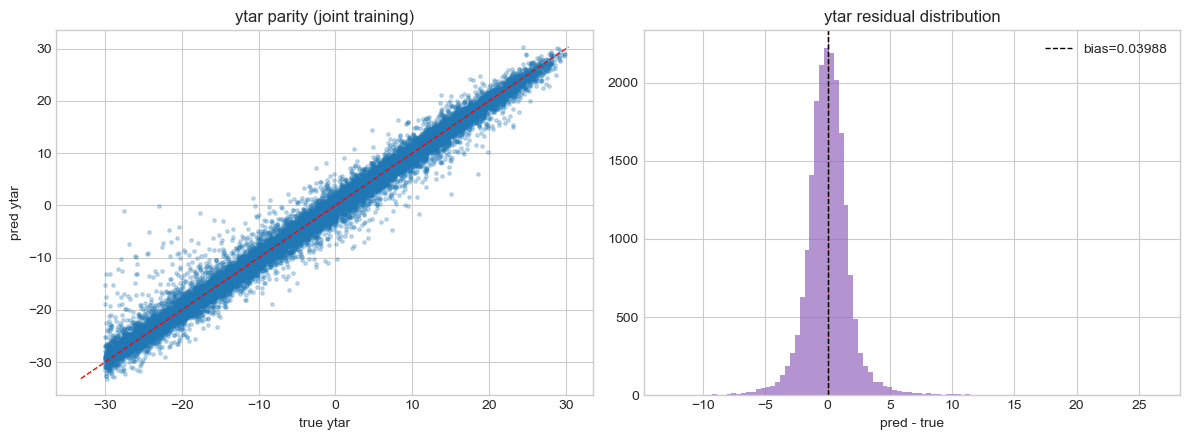

Skipping ytar-only probe (set RUN_YTAR_ONLY_PROBE=True to enable).


In [48]:
ytar_feature_diag = None
ytar_probe = None

if TARGET_MODE == 'all' and RUN_YTAR_FEATURE_DIAGNOSTICS:
    ytar_idx = bundle.target_names.index('ytar')
    ytar_all = bundle.Y[:, ytar_idx]

    diag_rows: list[dict[str, float | str]] = []
    for i, feature_name in enumerate(bundle.feature_names):
        diag_rows.append({
            'source': feature_name,
            'group': 'feature',
            'pearson_r': safe_corrcoef(bundle.X[:, i], ytar_all),
        })

    for i, target_name in enumerate(bundle.target_names):
        if target_name == 'ytar':
            continue
        diag_rows.append({
            'source': target_name,
            'group': 'truth_target',
            'pearson_r': safe_corrcoef(bundle.Y[:, i], ytar_all),
        })

    ytar_feature_diag = pd.DataFrame(diag_rows)
    ytar_feature_diag['abs_pearson_r'] = ytar_feature_diag['pearson_r'].abs()
    ytar_feature_diag = ytar_feature_diag.sort_values('abs_pearson_r', ascending=False, na_position='last')

    ytar_true = result['y_true'][:, ytar_idx]
    ytar_pred = result['y_pred'][:, ytar_idx]
    ytar_res = ytar_pred - ytar_true

    print('Top correlations with ytar:')
    display(ytar_feature_diag)
    print('ytar residual summary:')
    print({
        'rmse': float(result['rmse'][ytar_idx]),
        'mae': float(result['mae'][ytar_idx]),
        'bias': float(result['bias'][ytar_idx]),
        'resid_std': float(result['resid_std'][ytar_idx]),
        'relative_rmse_pct': float(100.0 * result['rel_rmse'][ytar_idx]),
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].scatter(ytar_true, ytar_pred, s=6, alpha=0.25)
    lo = min(float(np.min(ytar_true)), float(np.min(ytar_pred)))
    hi = max(float(np.max(ytar_true)), float(np.max(ytar_pred)))
    axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1)
    axes[0].set_title('ytar parity (joint training)')
    axes[0].set_xlabel('true ytar')
    axes[0].set_ylabel('pred ytar')

    axes[1].hist(ytar_res, bins=100, alpha=0.70, color='tab:purple')
    axes[1].axvline(0.0, color='r', linestyle='--', linewidth=1)
    axes[1].axvline(np.mean(ytar_res), color='k', linestyle='--', linewidth=1, label=f"bias={np.mean(ytar_res):.4g}")
    axes[1].set_title('ytar residual distribution')
    axes[1].set_xlabel('pred - true')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print('Skipping ytar feature diagnostics (set TARGET_MODE="all" and RUN_YTAR_FEATURE_DIAGNOSTICS=True to enable).')

if TARGET_MODE == 'all' and RUN_YTAR_ONLY_PROBE:
    print('Running ytar-only probe...')
    ytar_probe = run_training(
        X=bundle.X,
        Y=bundle.Y[:, [-1]],
        target_names=['ytar'],
        val_fraction=VAL_FRACTION,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        seed=SEED,
        hidden=MODEL_HIDDEN,
        n_blocks=MODEL_BLOCKS,
        dropout=DROPOUT,
        target_loss_weights={'ytar': 1.0},
        grad_clip_norm=GRAD_CLIP_NORM,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
        scheduler_patience=SCHEDULER_PATIENCE,
        scheduler_factor=SCHEDULER_FACTOR,
        min_lr=MIN_LR,
    )

    probe_df = pd.DataFrame([
        {
            'experiment': 'joint_all',
            'rmse_ytar': result['rmse'][-1],
            'mae_ytar': result['mae'][-1],
            'bias_ytar': result['bias'][-1],
            'best_epoch': result['best_epoch'],
        },
        {
            'experiment': 'ytar_only',
            'rmse_ytar': ytar_probe['rmse'][0],
            'mae_ytar': ytar_probe['mae'][0],
            'bias_ytar': ytar_probe['bias'][0],
            'best_epoch': ytar_probe['best_epoch'],
        },
    ])
    display(probe_df)
else:
    print('Skipping ytar-only probe (set RUN_YTAR_ONLY_PROBE=True to enable).')

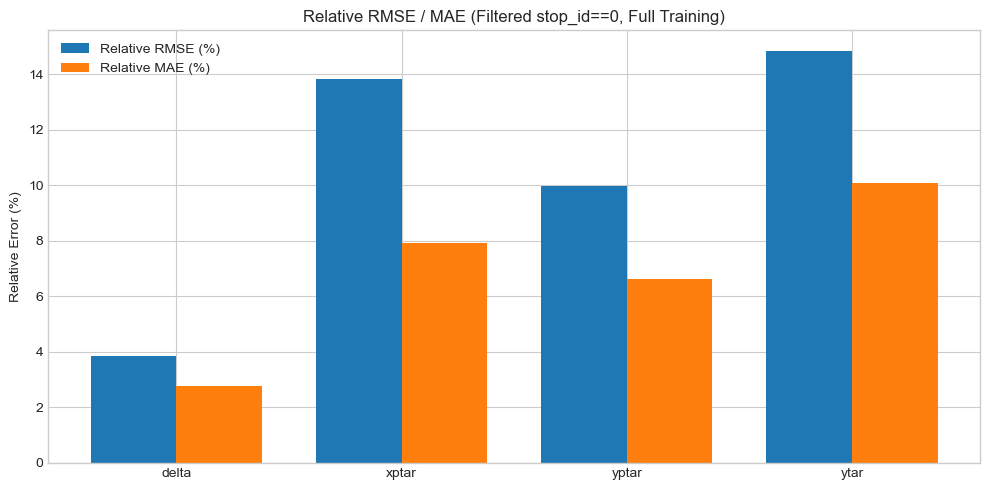

In [49]:
# 可视化1：全量训练下各目标相对 RMSE/MAE（%）
targets = bundle.target_names
rel_rmse_pct = [100.0 * result['rel_rmse'][i] for i in range(len(targets))]
rel_mae_pct = [100.0 * result['rel_mae'][i] for i in range(len(targets))]

x = np.arange(len(targets))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w / 2, rel_rmse_pct, width=w, label='Relative RMSE (%)')
ax.bar(x + w / 2, rel_mae_pct, width=w, label='Relative MAE (%)')
ax.set_xticks(x)
ax.set_xticklabels(targets)
ax.set_title('Relative RMSE / MAE (Filtered stop_id==0, Full Training)')
ax.set_ylabel('Relative Error (%)')
ax.legend()
plt.tight_layout()
plt.show()

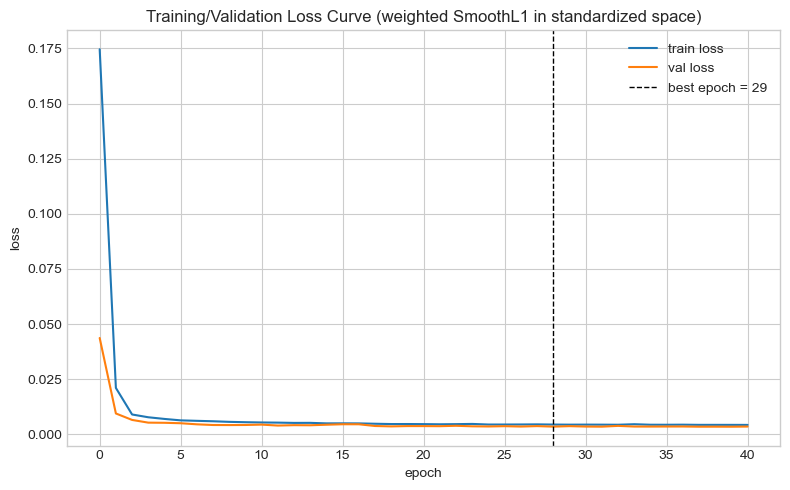

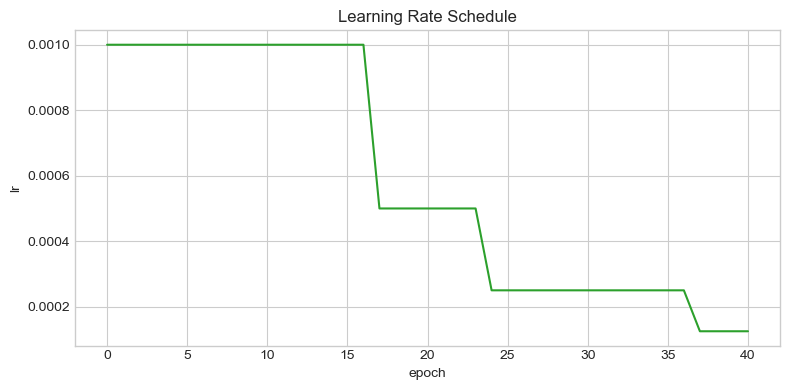

In [50]:
# 可视化2：训练/验证损失曲线
plt.figure(figsize=(8, 5))
plt.plot(result['train_loss_hist'], label='train loss')
plt.plot(result['val_loss_hist'], label='val loss')
if result['best_epoch'] > 0:
    plt.axvline(result['best_epoch'] - 1, color='k', linestyle='--', linewidth=1, label=f"best epoch = {result['best_epoch']}")
plt.title('Training/Validation Loss Curve (weighted SmoothL1 in standardized space)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(result['lr_hist'], color='tab:green')
plt.title('Learning Rate Schedule')
plt.xlabel('epoch')
plt.ylabel('lr')
plt.tight_layout()
plt.show()

In [51]:
print('n_train        =', result['n_train'])
print('n_val          =', result['n_val'])
print('best_epoch     =', result['best_epoch'])
print('best_val_loss  =', round(result['best_val_loss'], 6))
print('loss_weights   =', result['target_loss_weights'])
print('rmse           =', np.round(result['rmse'], 6).tolist())
print('mae            =', np.round(result['mae'], 6).tolist())
print('bias           =', np.round(result['bias'], 6).tolist())
print('resid_std      =', np.round(result['resid_std'], 6).tolist())
print('rel_rmse(%)    =', np.round(100.0 * np.array(result['rel_rmse']), 4).tolist())
print('rel_mae(%)     =', np.round(100.0 * np.array(result['rel_mae']), 4).tolist())

n_train        = 80000
n_val          = 20000
best_epoch     = 29
best_val_loss  = 0.003517
loss_weights   = {'delta': 1.0, 'xptar': 1.0, 'yptar': 1.0, 'ytar': 0.3499999940395355}
rmse           = [0.476803, 0.002748, 0.001592, 1.855741]
mae            = [0.345687, 0.001571, 0.001059, 1.262637]
bias           = [0.023696, 5.6e-05, 4.3e-05, 0.039877]
resid_std      = [0.476215, 0.002747, 0.001591, 1.855313]
rel_rmse(%)    = [3.84, 13.8364, 9.9725, 14.847]
rel_mae(%)     = [2.784, 7.9085, 6.6347, 10.1018]


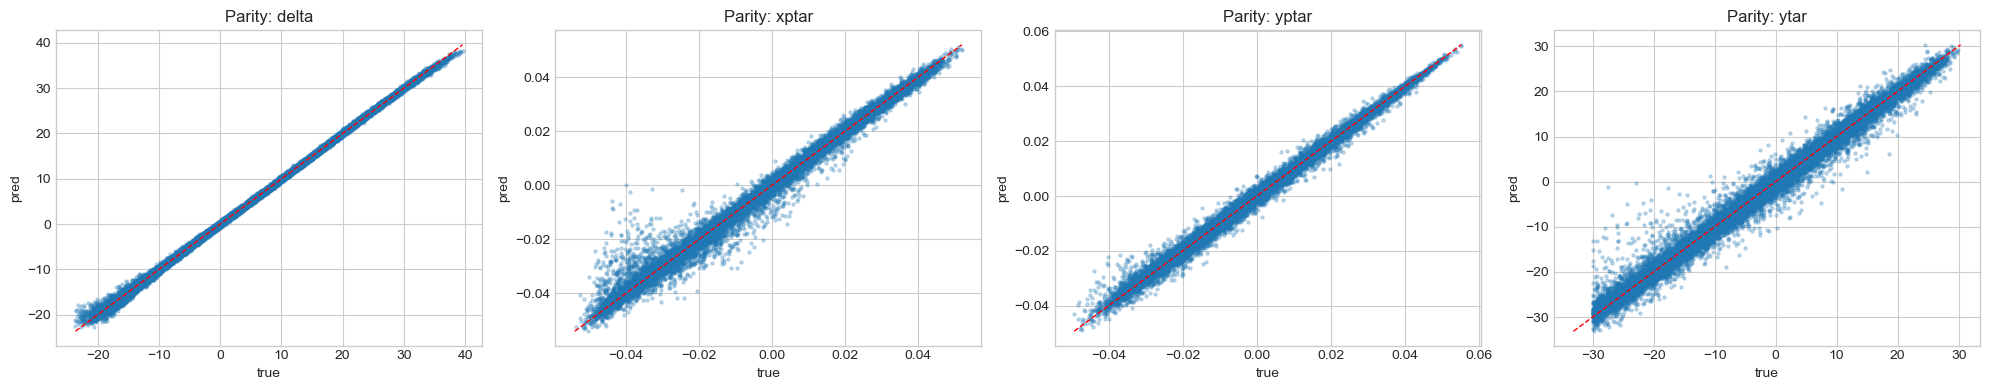

In [9]:
# 可视化3：预测 vs 真值（parity plot）
y_true = result['y_true']
y_pred = result['y_pred']
nt = y_true.shape[1]

fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if isinstance(axes, np.ndarray):
    axes_list = list(axes.ravel())
else:
    axes_list = [axes]

for i, t in enumerate(bundle.target_names):
    ax = axes_list[i]
    yt = y_true[:, i]
    yp = y_pred[:, i]
    ax.scatter(yt, yp, s=5, alpha=0.25)
    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(f'Parity: {t}')
    ax.set_xlabel('true')
    ax.set_ylabel('pred')

plt.tight_layout()
plt.show()

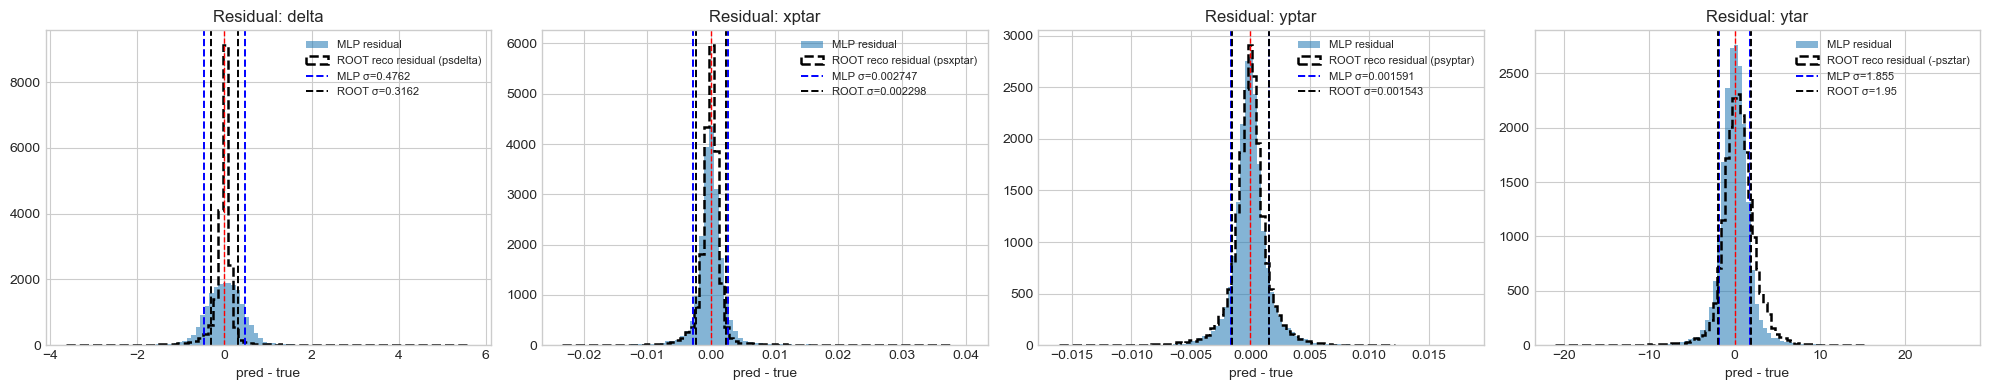

In [10]:
# 可视化4：残差分布（叠加 ROOT 重建 residual + 标准差虚线）
res = y_pred - y_true
val_idx = np.array(result['val_indices'], dtype=np.int64)
reco_val = bundle.Y_reco[val_idx]
res_root = reco_val - y_true

nt = res.shape[1]
fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if isinstance(axes, np.ndarray):
    axes_list = list(axes.ravel())
else:
    axes_list = [axes]

for i, t in enumerate(bundle.target_names):
    ax = axes_list[i]
    mlp_res = res[:, i]
    ax.hist(mlp_res, bins=80, alpha=0.55, label='MLP residual')

    rr = res_root[:, i]
    finite_mask = np.isfinite(rr)
    reco_branch = bundle.target_reco_branches[i]
    if np.any(finite_mask):
        root_res = rr[finite_mask]
        ax.hist(
            root_res,
            bins=80,
            histtype='step',
            color='k',
            linestyle='--',
            linewidth=1.8,
            label=f'ROOT reco residual ({reco_branch})',
        )
    else:
        root_res = np.array([])
        ax.text(0.03, 0.93, 'ROOT reco branch missing', transform=ax.transAxes, fontsize=9, va='top')

    mlp_std = float(np.std(mlp_res))
    ax.axvline(+mlp_std, color='b', linestyle='--', linewidth=1.4, label=f'MLP σ={mlp_std:.4g}')
    ax.axvline(-mlp_std, color='b', linestyle='--', linewidth=1.4)

    if root_res.size > 0:
        root_std = float(np.std(root_res))
        ax.axvline(+root_std, color='k', linestyle='--', linewidth=1.4, label=f'ROOT σ={root_std:.4g}')
        ax.axvline(-root_std, color='k', linestyle='--', linewidth=1.4)

    ax.axvline(0.0, color='r', linestyle='--', linewidth=1)
    ax.set_title(f'Residual: {t}')
    ax.set_xlabel('pred - true')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [54]:
# 保存结果（json + csv + png）
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
mode = TARGET_MODE

metrics_json = OUTPUT_DIR / f'notebook_metrics_{mode}_{stamp}.json'
metrics_csv = OUTPUT_DIR / f'notebook_metrics_{mode}_{stamp}.csv'
plot_rmse = OUTPUT_DIR / f'notebook_rel_rmse_mae_{mode}_{stamp}.png'
plot_parity = OUTPUT_DIR / f'notebook_parity_{mode}_{stamp}.png'
plot_resid = OUTPUT_DIR / f'notebook_residual_{mode}_{stamp}.png'
plot_loss = OUTPUT_DIR / f'notebook_loss_{mode}_{stamp}.png'
plot_lr = OUTPUT_DIR / f'notebook_lr_{mode}_{stamp}.png'
plot_ytar_diag = OUTPUT_DIR / f'notebook_ytar_diag_{mode}_{stamp}.png'

payload = {
    'root_file': str(ROOT_FILE.resolve()),
    'inp_file': str(INP_FILE.resolve()) if INP_FILE.exists() else None,
    'tree_name': TREE_NAME,
    'target_mode': TARGET_MODE,
    'filter_stop_id': FILTER_STOP_ID,
    'x_tar_mode': X_TAR_MODE,
    'feature_names': bundle.feature_names,
    'target_names': bundle.target_names,
    'target_truth_branches': bundle.target_truth_branches,
    'target_reco_branches': bundle.target_reco_branches,
    'max_events': MAX_EVENTS,
    'val_fraction': VAL_FRACTION,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'prefix': bundle.prefix,
    'p0_gev': P0,
    'model': {
        'hidden': MODEL_HIDDEN,
        'blocks': MODEL_BLOCKS,
        'dropout': DROPOUT,
    },
    'optimization': {
        'grad_clip_norm': GRAD_CLIP_NORM,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'early_stopping_min_delta': EARLY_STOPPING_MIN_DELTA,
        'scheduler_patience': SCHEDULER_PATIENCE,
        'scheduler_factor': SCHEDULER_FACTOR,
        'min_lr': MIN_LR,
        'target_loss_weights': result['target_loss_weights'],
    },
    'events': {
        'all': bundle.n_all,
        'after_filter': bundle.n_after_filter,
    },
    'metrics': {
        'n_train': result['n_train'],
        'n_val': result['n_val'],
        'best_epoch': result['best_epoch'],
        'best_val_loss': result['best_val_loss'],
        'best_val_loss_per_target': result['best_val_loss_per_target'],
        'rmse': result['rmse'],
        'mae': result['mae'],
        'bias': result['bias'],
        'resid_std': result['resid_std'],
        'rel_rmse': result['rel_rmse'],
        'rel_mae': result['rel_mae'],
    },
    'ytar_feature_diag': (
        ytar_feature_diag.to_dict(orient='records')
        if isinstance(ytar_feature_diag, pd.DataFrame)
        else None
    ),
    'ytar_probe': (
        {
            'best_epoch': ytar_probe['best_epoch'],
            'best_val_loss': ytar_probe['best_val_loss'],
            'rmse': ytar_probe['rmse'],
            'mae': ytar_probe['mae'],
            'bias': ytar_probe['bias'],
            'resid_std': ytar_probe['resid_std'],
        }
        if isinstance(ytar_probe, dict)
        else None
    ),
}

with open(metrics_json, 'w', encoding='utf-8') as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

df_metrics.to_csv(metrics_csv, index=False)

# 重新绘图并保存（相对 RMSE/MAE）
targets = bundle.target_names
rel_rmse_pct = [100.0 * result['rel_rmse'][i] for i in range(len(targets))]
rel_mae_pct = [100.0 * result['rel_mae'][i] for i in range(len(targets))]
x = np.arange(len(targets))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w / 2, rel_rmse_pct, width=w, label='Relative RMSE (%)')
ax.bar(x + w / 2, rel_mae_pct, width=w, label='Relative MAE (%)')
ax.set_xticks(x)
ax.set_xticklabels(targets)
ax.set_title('Relative RMSE / MAE (Filtered stop_id==0, Full Training)')
ax.set_ylabel('Relative Error (%)')
ax.legend()
plt.tight_layout()
plt.savefig(plot_rmse, dpi=150)
plt.close(fig)

# 保存 loss 图
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(result['train_loss_hist'], label='train loss')
ax.plot(result['val_loss_hist'], label='val loss')
if result['best_epoch'] > 0:
    ax.axvline(result['best_epoch'] - 1, color='k', linestyle='--', linewidth=1, label=f"best epoch = {result['best_epoch']}")
ax.set_title('Training/Validation Loss Curve (weighted SmoothL1 in standardized space)')
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.legend()
plt.tight_layout()
plt.savefig(plot_loss, dpi=150)
plt.close(fig)

# 保存 learning-rate 图
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(result['lr_hist'], color='tab:green')
ax.set_title('Learning Rate Schedule')
ax.set_xlabel('epoch')
ax.set_ylabel('lr')
plt.tight_layout()
plt.savefig(plot_lr, dpi=150)
plt.close(fig)

# 保存 parity 图
y_true = result['y_true']
y_pred = result['y_pred']
nt = y_true.shape[1]
fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if isinstance(axes, np.ndarray):
    axes_list = list(axes.ravel())
else:
    axes_list = [axes]
for i, t in enumerate(bundle.target_names):
    ax = axes_list[i]
    yt = y_true[:, i]
    yp = y_pred[:, i]
    ax.scatter(yt, yp, s=5, alpha=0.25)
    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_title(f'Parity: {t}')
    ax.set_xlabel('true')
    ax.set_ylabel('pred')
plt.tight_layout()
plt.savefig(plot_parity, dpi=150)
plt.close(fig)

# 保存 residual 图（叠加 ROOT 重建 residual + 标准差虚线）
res = y_pred - y_true
val_idx = np.array(result['val_indices'], dtype=np.int64)
reco_val = bundle.Y_reco[val_idx]
res_root = reco_val - y_true

nt = res.shape[1]
fig, axes = plt.subplots(1, nt, figsize=(5 * nt, 4))
if isinstance(axes, np.ndarray):
    axes_list = list(axes.ravel())
else:
    axes_list = [axes]
for i, t in enumerate(bundle.target_names):
    ax = axes_list[i]
    mlp_res = res[:, i]
    ax.hist(mlp_res, bins=80, alpha=0.55, label='MLP residual')

    rr = res_root[:, i]
    finite_mask = np.isfinite(rr)
    reco_branch = bundle.target_reco_branches[i]
    if np.any(finite_mask):
        root_res = rr[finite_mask]
        ax.hist(
            root_res,
            bins=80,
            histtype='step',
            color='k',
            linestyle='--',
            linewidth=1.8,
            label=f'ROOT reco residual ({reco_branch})',
        )
    else:
        root_res = np.array([])
        ax.text(0.03, 0.93, 'ROOT reco branch missing', transform=ax.transAxes, fontsize=9, va='top')

    mlp_std = float(np.std(mlp_res))
    ax.axvline(+mlp_std, color='b', linestyle='--', linewidth=1.4, label=f'MLP σ={mlp_std:.4g}')
    ax.axvline(-mlp_std, color='b', linestyle='--', linewidth=1.4)

    if root_res.size > 0:
        root_std = float(np.std(root_res))
        ax.axvline(+root_std, color='k', linestyle='--', linewidth=1.4, label=f'ROOT σ={root_std:.4g}')
        ax.axvline(-root_std, color='k', linestyle='--', linewidth=1.4)

    ax.axvline(0.0, color='r', linestyle='--', linewidth=1)
    ax.set_title(f'Residual: {t}')
    ax.set_xlabel('pred - true')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(plot_resid, dpi=150)
plt.close(fig)

# 保存 ytar 诊断图（如适用）
if TARGET_MODE == 'all':
    ytar_idx = bundle.target_names.index('ytar')
    ytar_true = result['y_true'][:, ytar_idx]
    ytar_pred = result['y_pred'][:, ytar_idx]
    ytar_res = ytar_pred - ytar_true

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].scatter(ytar_true, ytar_pred, s=6, alpha=0.25)
    lo = min(float(np.min(ytar_true)), float(np.min(ytar_pred)))
    hi = max(float(np.max(ytar_true)), float(np.max(ytar_pred)))
    axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1)
    axes[0].set_title('ytar parity (joint training)')
    axes[0].set_xlabel('true ytar')
    axes[0].set_ylabel('pred ytar')

    axes[1].hist(ytar_res, bins=100, alpha=0.70, color='tab:purple')
    axes[1].axvline(0.0, color='r', linestyle='--', linewidth=1)
    axes[1].axvline(np.mean(ytar_res), color='k', linestyle='--', linewidth=1, label=f"bias={np.mean(ytar_res):.4g}")
    axes[1].set_title('ytar residual distribution')
    axes[1].set_xlabel('pred - true')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(plot_ytar_diag, dpi=150)
    plt.close(fig)

print('Saved:')
print('-', metrics_json.resolve())
print('-', metrics_csv.resolve())
print('-', plot_rmse.resolve())
print('-', plot_loss.resolve())
print('-', plot_lr.resolve())
print('-', plot_parity.resolve())
print('-', plot_resid.resolve())
if TARGET_MODE == 'all':
    print('-', plot_ytar_diag.resolve())

Saved:
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\mlp_reduced_data_test\outputs_notebook\notebook_metrics_all_20260409_033420.json
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\mlp_reduced_data_test\outputs_notebook\notebook_metrics_all_20260409_033420.csv
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\mlp_reduced_data_test\outputs_notebook\notebook_rel_rmse_mae_all_20260409_033420.png
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\mlp_reduced_data_test\outputs_notebook\notebook_loss_all_20260409_033420.png
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\mlp_reduced_data_test\outputs_notebook\notebook_lr_all_20260409_033420.png
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\mlp_reduced_data_test\outputs_notebook\notebook_parity_all_20260409_033420.png
- C:\Users\Lanto\Desktop\AI_ML R-SIDIS\SHMS_Calibration_NN\experiments\mlp_reduced_data_te